# Raumakustik: Analyse und Design, SoSe 2026
## Hausaufgabe I

## Hinweise

Abzugeben ist eine Jupyter Notebook Datei mit Text und Python Code einschließlich daraus erzeugten Abbildungen. Achten Sie darauf, dass alle formalen Anforderungen eines wissenschaftlichen Textes (Literaturverweise, gut beschriftete Abbildungen etc.) erfüllt sind und dass der Code gut dokumentiert und ausführbar ist. 

Abgabetermin ist **Dienstag, 26. Mai 2026 (23:59 Uhr)**. Das Jupyter-Notebook ist gemäß der Namenskonvention *Gruppe_Gruppenbezeichnung_Hausaufgabe_001.ipynb* umzubenennen. Das zugehörige .zip-Archiv soll den Namen *Gruppe_Gruppenbezeichnung_Hausaufgabe_001.zip* tragen und alle zum Ausführen des Notebooks erforderlichen Dateien enthalten.

Der Upload erfolgt über ISIS und ist nur bis 23:59 Uhr möglich. Nach Ablauf dieser Frist wird das Upload-Fenster geschlossen und spätere Abgaben über ISIS können nicht mehr berücksichtigt werden.



In [1]:
# Zur Lösung der Hausaufgabe können folgende Module verwendet werden

import numpy as np
import scipy as sc 
import matplotlib.pyplot as plt
import pyfar as pf
import IPython.display as ipd

#### Gruppe 
**Name / Matrikelnummer**  
Person 1 /  Felix Flaxl 505623  
Person 2 /  Ramon Mindel 466070  
Person 3 /  Aard Hoekstra 466039

## Aufgabe 1 Oktavbandfilterung

a) Erzeugen Sie mit dem Modul **Scipy (kein pyfar!)** eine Bandpass-Filterbank für akustische Analysen in Oktavbändern mit Mittenfrequenzen von 125 Hz bis 8 kHz.

Verwenden Sie Butterworth-Filter 10. Ordnung und eine Filterstruktur mit einer Serie von Biquad-Filtern (second order sections) und einer Samplingrate von 44100 Hz.

Zeigen Sie exemplarisch, dass im Oktavband mit $f_m $= 1 kHz die Anforderungen der DIN EN 61260-1 für Oktavfilter der Klasse 1 erfüllt sind, indem Sie den Amplitudengang des Filters und die Toleranzgrenzen der DIN plotten. 

(3 Punkte)

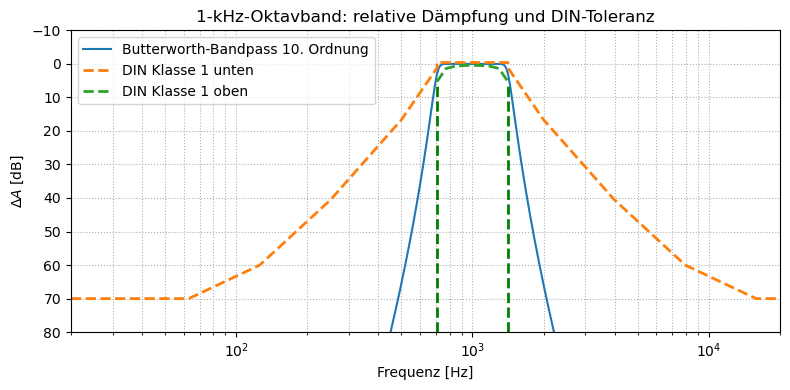

In [2]:
# Mittenfrequenzen und Samplerate
f_m = np.array([125, 250, 500, 1000, 2000, 4000, 8000], dtype=float)
f_s = 44100
G = 10**(3/10)

# Oktavbandgrenzen
f_1 = f_m / np.sqrt(G)
f_2 = f_m * np.sqrt(G)


# Scypi Filterbank als SOS

sos_filter = []

for i in range(len(f_m)):
    sos = sc.signal.butter(10, [f_1[i], f_2[i]], btype='bandpass', fs=f_s, output='sos')
    sos_filter.append(sos)


# 1kHz Band auswählen

idx = np.where(f_m == 1000)[0][0]
sos_1k = sos_filter[idx]

w, h = sc.signal.sosfreqz(sos_1k, worN=4096, fs=f_s)

# Relative Dämpfung des Filters
delta_A = -20 * np.log10(np.maximum(np.abs(h), 1e-12))


# DIN Toleranzkurven einzeichnen

eps = 1e-6

# Normierte Frequenzen
Omega_lower = np.array([
    G**(-4),
    G**(-3),
    G**(-2),
    G**(-1),
    G**(-1/2) - eps,
    G**(-1/2) + eps,
    G**(-3/8),
    G**(-1/4),
    G**(-1/8),
    1.0,
    G**(1/8),
    G**(1/4),
    G**(3/8),
    G**(1/2) - eps,
    G**(1/2) + eps,
    G**(1),
    G**(2),
    G**(3),
    G**(4)
], dtype=float)

# Untere Grenze
A_lower = np.array([
    70.0,
    60.0,
    40.5,
    16.6,
    1.2,
    -0.4,
    -0.4,
    -0.4,
    -0.4,
    -0.4,
    -0.4,
    -0.4,
    -0.4,
    -0.4,
    1.2,
    16.6,
    40.5,
    60.0,
    70.0
])

# Obere Grenze
Omega_upper = np.array([
    G**(-1/2) + eps,
    G**(-3/8),
    G**(-1/4),
    G**(-1/8),
    1.0,
    G**(1/8),
    G**(1/4),
    G**(3/8),
    G**(1/2) - eps
], dtype=float)

A_upper = np.array([5.3, 1.4, 0.7, 0.5, 0.4, 0.5, 0.7, 1.4, 5.3])

# Normierte Frequenzen in reale Frequenzen
f_lower = Omega_lower * 1000.0
f_upper = Omega_upper * 1000.0

# Plot

plt.figure(figsize=(8, 4))

# Filter als relative Dämpfung
plt.semilogx(w, delta_A, label='Butterworth-Bandpass 10. Ordnung')

# Grenzen
f_lower_plot = np.concatenate(([20.0], f_lower, [20000.0]))
A_lower_plot = np.concatenate(([A_lower[0]], A_lower, [A_lower[-1]]))

plt.semilogx(f_lower_plot, A_lower_plot, '--', linewidth=2, label='DIN Klasse 1 unten')
plt.semilogx(f_upper, A_upper, '--', linewidth=2, label='DIN Klasse 1 oben')
plt.vlines([f_upper[0], f_upper[-1]], [80, 80], [A_upper[0], A_upper[-1]], colors='green', linestyles='--', linewidth=2)

plt.title('1-kHz-Oktavband: relative Dämpfung und DIN-Toleranz')
plt.xlabel('Frequenz [Hz]')
plt.ylabel(r'$\Delta A$ [dB]')
plt.xlim(20, 20000)
plt.ylim(80, -10)
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()


b) Erzeugen Sie eine Oktav-Filterbank in **Pyfar** und prüfen Sie ebenfalls die Anforderungen nach DIN 61260-1. 

(2 Punkte)

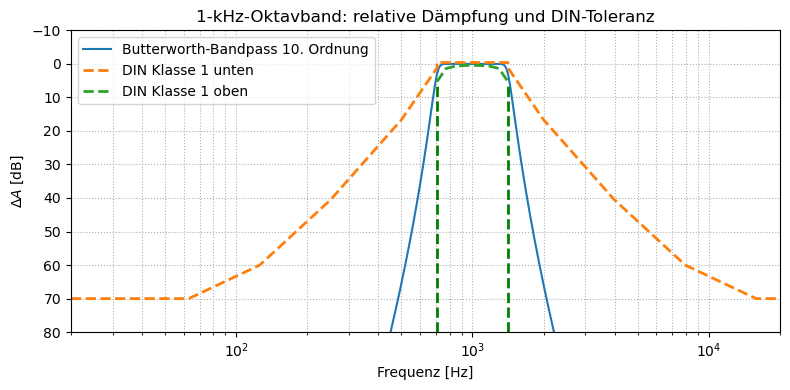

In [3]:
# Loesung Aufgabe 1b

# Pyfar Filterbank als SOS
pf_filterbank = []

pf_filterbank = pf.dsp.filter.fractional_octave_bands(signal=None, num_fractions=1, sampling_rate=f_s, frequency_range=(f_m[0], f_m[-1]), order=10)

# Passende Pyfar-Freqs
f_m_nom, _ = pf.dsp.filter.fractional_octave_frequencies(num_fractions=1, frequency_range=(f_m[0], f_m[-1]))

idx = np.where(np.isclose(f_m_nom, 1000))[0][0]

# 1kHz Band
sos_1k = np.squeeze(pf_filterbank.coefficients[idx])

# Frequenzgang mit Scypi aus den pyfar-SOS-Koeffizienten
w, h = sc.signal.sosfreqz(sos_1k, worN=4096, fs=f_s)


# Plot

plt.figure(figsize=(8, 4))

# Filter als relative Dämpfung
plt.semilogx(w, delta_A, label='Butterworth-Bandpass 10. Ordnung')

# Grenzen
f_lower_plot = np.concatenate(([20.0], f_lower, [20000.0]))
plt.semilogx(f_lower_plot, A_lower_plot, '--', linewidth=2, label='DIN Klasse 1 unten')

A_lower_plot = np.concatenate(([A_lower[0]], A_lower, [A_lower[-1]]))
plt.semilogx(f_upper, A_upper, '--', linewidth=2, label='DIN Klasse 1 oben')
plt.vlines([f_upper[0], f_upper[-1]], [80, 80], [A_upper[0], A_upper[-1]], colors='green', linestyles='--', linewidth=2)

plt.title('1-kHz-Oktavband: relative Dämpfung und DIN-Toleranz')
plt.xlabel('Frequenz [Hz]')
plt.ylabel(r'$\Delta A$ [dB]')
plt.xlim(20, 20000)
plt.ylim(80, -10)
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

## Aufgabe 2

Die folgende Berechnung entspricht einer leicht vereinfachten Version des in

**Lundeby, A., Vigran, T. E., Bietz, H., & Vorländer, M. (1995). Uncertainties of measurements in room acoustics. Acta Acustica united with Acustica, 81(4), 344-355.**

beschriebenen Vorgehens. 

a. Laden Sie die im Teatro Olimpico (Vicenza) gemessene Impulsantwort mit pyfar ein. 

Bestimmen Sie den **Anfangspunkt** der Impulsantwort nach DIN 3382 und führen Sie eine entsprechende zeitliche Verschiebung durch. 

Kürzen Sie die Gesamtlänge der Impulsantwort auf 4.5 Sekunden mit einem zeitlichen Fenster. 

Berechnen Sie mit einer der oben erzeugten Filterbank die Oktavbandpass-gefilterten Impulsantworten und plotten diese als quadrierte und auf den Maximalwert als 0 dB-Punkt normierte und logarithmierte Kurven. 

**Die folgenden Berechnungsschritte sollen für jedes Oktavband durchgeführt werden.** 

(2 Punkte)

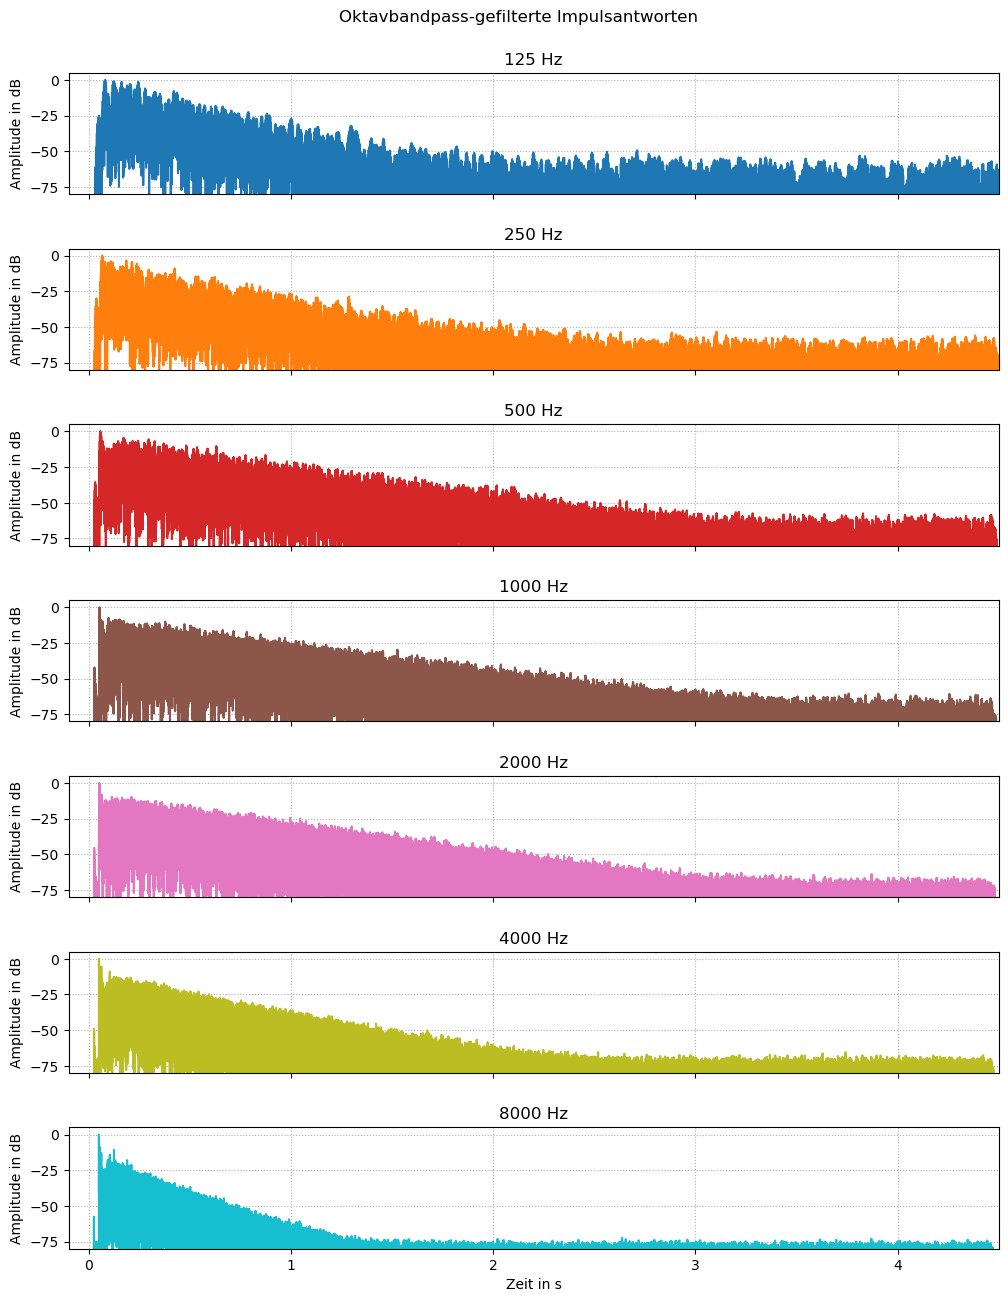

<Figure size 1100x600 with 0 Axes>

In [4]:
# Loesung Aufgabe 2a

#Impulsantwort einlesen
ir = pf.io.read_audio("RIR_Vicenza.wav")

# Startpunkt bestimmen
start = pf.dsp.find_impulse_response_start(ir, threshold=20)

# Zeitliche Verschiebung, sodass Start bei t=0, letzte 50ms Fade
rir_aligned = pf.dsp.time_shift(ir, start, unit="samples", mode="linear")

rir_windowed = pf.dsp.time_window(rir_aligned, interval=[4.45, 4.5], shape="right", window="hann", unit="s", crop="end")

# Impulsantwort durch Filterbank
rir_bands = pf_filterbank.process(rir_windowed)

#Plot Vorbereitung
t = np.arange(rir_bands.time.shape[-1]) / rir_bands.sampling_rate
fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, 7))

plt.figure(figsize=(11, 6))

#Qadrieren, auf Maximum normieren in dB darstellen
for i, fm in enumerate(f_m):
    x = np.squeeze(rir_bands.time[i])
    x2 = x**2
    x2_db = 10 * np.log10(np.maximum(x2 / np.max(x2), 1e-12))

    axes[i].plot(t, x2_db, color=colors[i])
    axes[i].set_title(f"{int(fm)} Hz")
    axes[i].set_ylabel("Amplitude in dB")
    axes[i].grid(True, which="both", linestyle=":")

    axes[i].set_ylim(-80, 5)
    axes[i].set_xlim(-0.1, 4.5)

axes[-1].set_xlabel("Zeit in s")
fig.suptitle("Oktavbandpass-gefilterte Impulsantworten", y=0.995)
fig.subplots_adjust(top=0.95, hspace=0.45)
plt.tight_layout()
plt.show()


b. Berechnen Sie geglättete und wiederum normierte Versionen der quadrierten Impulsantwort als gleitenden Mittelwert mit einem Rechteckfenster von 50 ms Länge und Normierung auf das Maximum der geglätteten Kurve (0 dB-Punkt). 

Plotten Sie diese für die sieben Oktavbänder.

 (2 Punkte)

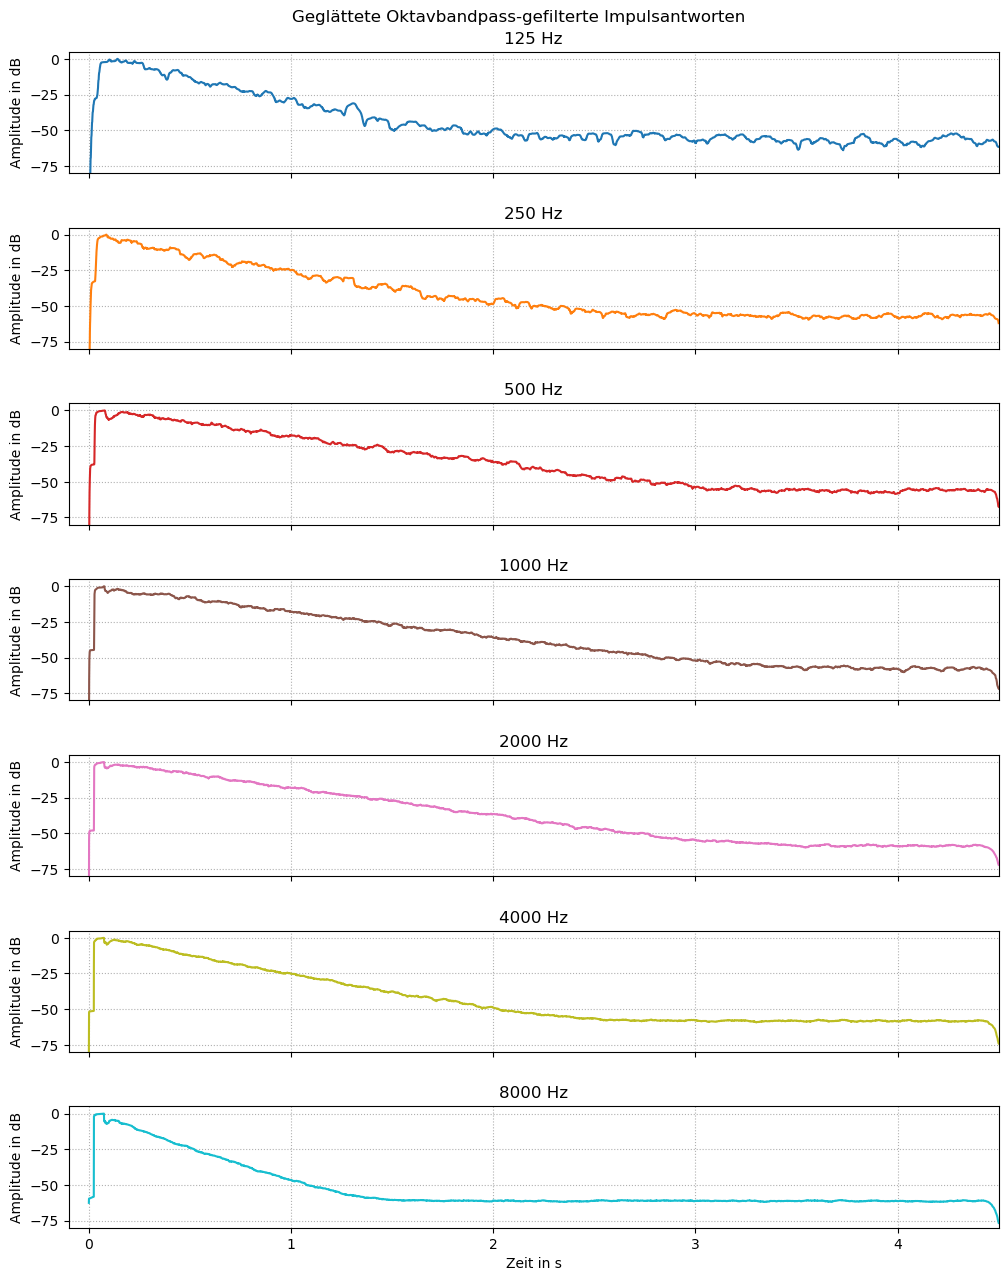

In [5]:
# Loesung Aufgabe 2b

# Fenster
window_ms = 50e-3
window_len = int(round(window_ms * rir_bands.sampling_rate))

if window_len < 1:
    window_len = 1

rect = np.ones(window_len) / window_len

fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, 7))

for i, fm in enumerate(f_m):
    x = np.squeeze(rir_bands.time[i])
    x2 = x**2

    #gleitender Mittelwert
    x2_smooth = np.convolve(x2, rect, mode="same")

    # Normierung auf Maximum
    x2_smooth_db = 10 * np.log10(np.maximum(x2_smooth / np.max(x2_smooth), 1e-12))

    #Plot
    axes[i].plot(t, x2_smooth_db, color=colors[i])
    axes[i].set_title(f"{int(fm)} Hz")
    axes[i].set_ylabel("Amplitude in dB")
    axes[i].grid(True, which="both", linestyle=":")
    axes[i].set_ylim(-80, 5)
    axes[i].set_xlim(-0.1, 4.5)

axes[-1].set_xlabel("Zeit in s")
fig.suptitle("Geglättete Oktavbandpass-gefilterte Impulsantworten", y=0.98)
fig.subplots_adjust(top=0.95, hspace=0.45)
plt.show()


c. Bestimmen Sie den Anfangspunkt der Impulsantworten als das Maximum der geglätteten Kurve und das Ende der Impulsantwort als Schnittpunkt einer initialen Schätzung der Steigung der geglätteten Kurve mit dem Noise Floor. 

Die Steigung soll als lineare Regression zwischen dem Maximum der geglätteten Kurve und einem Punkt 10 dB oberhalb des Noise Floors berechnet werden. Der Noise Floor wird dabei als energetischer Mittelwert im Zeitintervall von **10 % bis 4,3 s** der Impulsantwort bestimmt.

Markieren Sie folgende Punkte in den Plots:

- Intervall zur Bestimmung des Noise Floor
- Anfangspunkt Impulsantwort 
- Noise Level
- Schnittpunkt der linearen Regression mit dem Noise Floor 
- Punkt 10 dB oberhalb des Noise Floors

(3 Punkte)

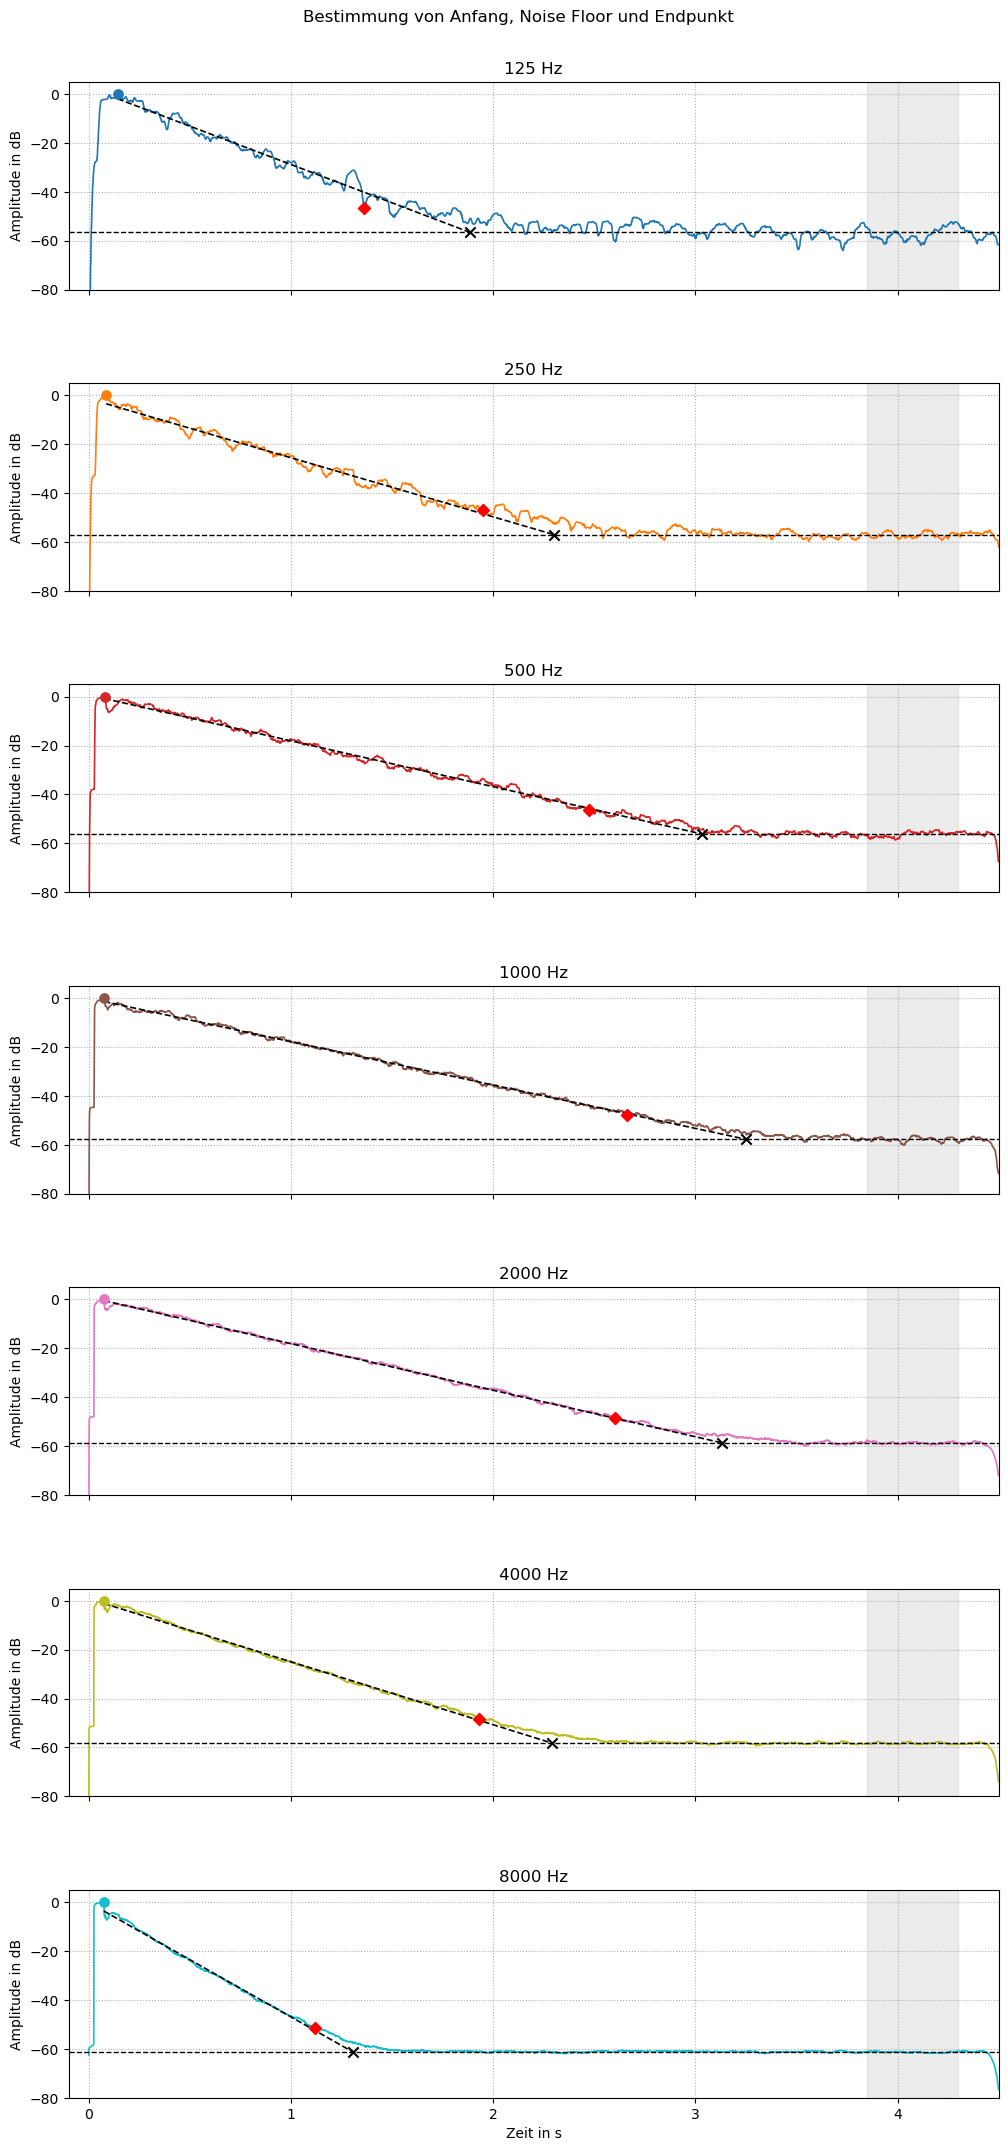

In [6]:
# Loesung Aufgabe 2c

# Listen für 2d), 2e) erstellen
noise_floor_db_list = []
m_list = []
t_end_list = []
t_start_list = []

t_noise_start = 4.3 - 0.1 * 4.5   #= 3.85 s
t_noise_end = 4.3

#Plots vorbereiten
fig, axes = plt.subplots(7, 1, figsize=(12, 24), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, 7))

for i, fm in enumerate(f_m):
    x = np.squeeze(rir_bands.time[i])
    x2 = x**2

    # Glättung
    x2_smooth = np.convolve(x2, rect, mode="same")

    # Normierung auf Maximum und Darstellung in dB
    x2_smooth_db = 10 * np.log10(np.maximum(x2_smooth / np.max(x2_smooth), 1e-12))

    #Noise Floor als energetischer Mittelwert im Intervall 3.85s bis 4.3s
    noise_mask = (t >= t_noise_start) & (t <= t_noise_end)
    noise_floor_lin = np.mean(x2_smooth[noise_mask])
    noise_floor_db = 10 * np.log10(np.maximum(noise_floor_lin / np.max(x2_smooth), 1e-12))

    # Anfangspunkt = Maximum
    idx_peak = np.argmax(x2_smooth_db)
    t_peak = t[idx_peak]
    y_peak = x2_smooth_db[idx_peak]
    t_start_list.append(t_peak)   # neu

    # Punkt 10 dB oberhalb des Noise Floors
    target_db = noise_floor_db + 10
    idx_10_candidates = np.where(x2_smooth_db[idx_peak:] <= target_db)[0]
    if len(idx_10_candidates) > 0:
        idx_10 = idx_peak + idx_10_candidates[0]
    else:
        idx_10 = len(t) - 1

    if idx_10 <= idx_peak + 1:
        idx_10 = min(idx_peak + 2, len(t) - 1)

    t_fit = t[idx_peak:idx_10 + 1]
    y_fit = x2_smooth_db[idx_peak:idx_10 + 1]

    # Lineare Regression über Bereich zwischen Peak und Punkt 10 dB über Noise Floor
    m, b = np.polyfit(t_fit, y_fit, 1)

    # Schnittpunkt Regressionsgeraden mit Noise Floor
    if np.abs(m) < 1e-12:
        t_end = np.nan
    else:
        t_end = (noise_floor_db - b) / m

        # Werte für 2d) speichern
        noise_floor_db_list.append(noise_floor_db)
        m_list.append(m)
        t_end_list.append(t_end)

    # Plot
    axes[i].plot(t, x2_smooth_db, color=colors[i], linewidth=1.2)
    axes[i].axvspan(t_noise_start, t_noise_end, color="gray", alpha=0.15)
    axes[i].axhline(noise_floor_db, color="black", linestyle="--", linewidth=1)

    if np.isfinite(t_end):
        t_line = np.array([t_peak, min(t_end, t[-1])])
        y_line = m * t_line + b
        axes[i].plot(t_line, y_line, color="black", linestyle="--", linewidth=1.2)

    axes[i].scatter(t_peak, y_peak, color=colors[i], marker="o", s=45, zorder=5)
    axes[i].scatter(t[idx_10], target_db, color="red", marker="D", s=38, zorder=5)

    if np.isfinite(t_end) and (t[0] <= t_end <= t[-1]):
        axes[i].scatter(t_end, noise_floor_db, color="black", marker="x", s=55, zorder=6)

    axes[i].set_title(f"{int(fm)} Hz")
    axes[i].set_ylabel("Amplitude in dB")
    axes[i].grid(True, which="both", linestyle=":")
    axes[i].set_ylim(-80, 5)
    axes[i].set_xlim(-0.1, 4.5)

# Listen für 2d), 2e) in Arrays umwandeln
noise_floor_db_array = np.array(noise_floor_db_list)
m_array = np.array(m_list)
t_end_array = np.array(t_end_list)
t_start_array = np.array(t_start_list)

#Plot
axes[-1].set_xlabel("Zeit in s")
fig.suptitle("Bestimmung von Anfang, Noise Floor und Endpunkt", y=0.98)
fig.subplots_adjust(top=0.95, hspace=0.45)
plt.show()

Der grau hinterlegte Bereich wurde für die Bestimmung des Noise Floors verwendet und zwar von $3,85\mathrm{s}$ ($ = 4,3\mathrm{s} - 10\% \cdot 4,3\mathrm{s}$) bis $4,3\mathrm{s}$.  
Die waagrechte gestrichelte Linie ergibt daraus den Noise Floor.

Der rot markierte Punkt liegt $10\mathrm{dB}$ über dem Noise Floor.

Der bunte Punkt ist der Anfangspunkt der Impulsantwort beim Maximum der geglätteten Kurve.  
Die fallende senkrechte Linie ergibt dann die Regression zwischen allen Punkten zwischen dem Maximum und dem Punkt $10\mathrm{dB}$ über dem Noise Floor.

d. Berechnen Sie für jede dieser Kurven eine Kompensationsenergie Ecomp für den durch den Noise Floor verdeckten Teil des Ausklangs nach Lundeby et al. (1995, S. 347f.) 

(3 Punkte)

In [7]:
# Loesung Aufgabe 2d
Ecomp_list = []

for nf_db, m in zip(noise_floor_db_array, m_array):
    # m ist in dB/s, sollte negativ sein
    if m >= 0:
        Ecomp = np.nan
    else:
        Ecomp = (10.0 / (-np.log(10.0) * m)) * 10**(nf_db / 10.0)

    Ecomp_list.append(Ecomp)

Ecomp_array = np.asarray(Ecomp_list)

#Prints
for i, fm in enumerate(f_m):
    print(f"Oktavband {int(fm)} Hz:")
    print(f"  Startpunkt Impulsantwort: {t_start_array[i]:.3f} s")
    print(f"  Noise Floor: {noise_floor_db_array[i]:.2f} dB")
    print(f"  Schnittpunkt mit Noise Floor: {t_end_array[i]:.3f} s")
    print(f"  Steigung der Regressionsgeraden: {m_array[i]:.2f} dB/s")
    print(f"  Ecomp: {Ecomp_array[i]:.6e}")
    print()
    

Oktavband 125 Hz:
  Startpunkt Impulsantwort: 0.142 s
  Noise Floor: -56.61 dB
  Schnittpunkt mit Noise Floor: 1.885 s
  Steigung der Regressionsgeraden: -31.35 dB/s
  Ecomp: 3.020908e-07

Oktavband 250 Hz:
  Startpunkt Impulsantwort: 0.085 s
  Noise Floor: -57.03 dB
  Schnittpunkt mit Noise Floor: 2.303 s
  Steigung der Regressionsgeraden: -24.17 dB/s
  Ecomp: 3.564443e-07

Oktavband 500 Hz:
  Startpunkt Impulsantwort: 0.078 s
  Noise Floor: -56.17 dB
  Schnittpunkt mit Noise Floor: 3.033 s
  Steigung der Regressionsgeraden: -18.74 dB/s
  Ecomp: 5.599238e-07

Oktavband 1000 Hz:
  Startpunkt Impulsantwort: 0.076 s
  Noise Floor: -57.73 dB
  Schnittpunkt mit Noise Floor: 3.248 s
  Steigung der Regressionsgeraden: -17.74 dB/s
  Ecomp: 4.130488e-07

Oktavband 2000 Hz:
  Startpunkt Impulsantwort: 0.075 s
  Noise Floor: -58.68 dB
  Schnittpunkt mit Noise Floor: 3.131 s
  Steigung der Regressionsgeraden: -19.03 dB/s
  Ecomp: 3.092903e-07

Oktavband 4000 Hz:
  Startpunkt Impulsantwort: 0.075 

e. Berechnen Sie unter Verwendung des oben ermittelten Anfangs- und Endpunkts der Impulsantwort und der Kompensationsenergie Ecomp die Decay Curve als Rückwärtsintegration der quadrierten Impulsantwort (Schroeder-Integral). Plotten Sie diese für die sieben Oktavbänder. 

(2 Punkte)

/var/folders/b_/mc3xbqdj2bx4fknp8n2ttjq00000gn/T/ipykernel_3562/2748298205.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


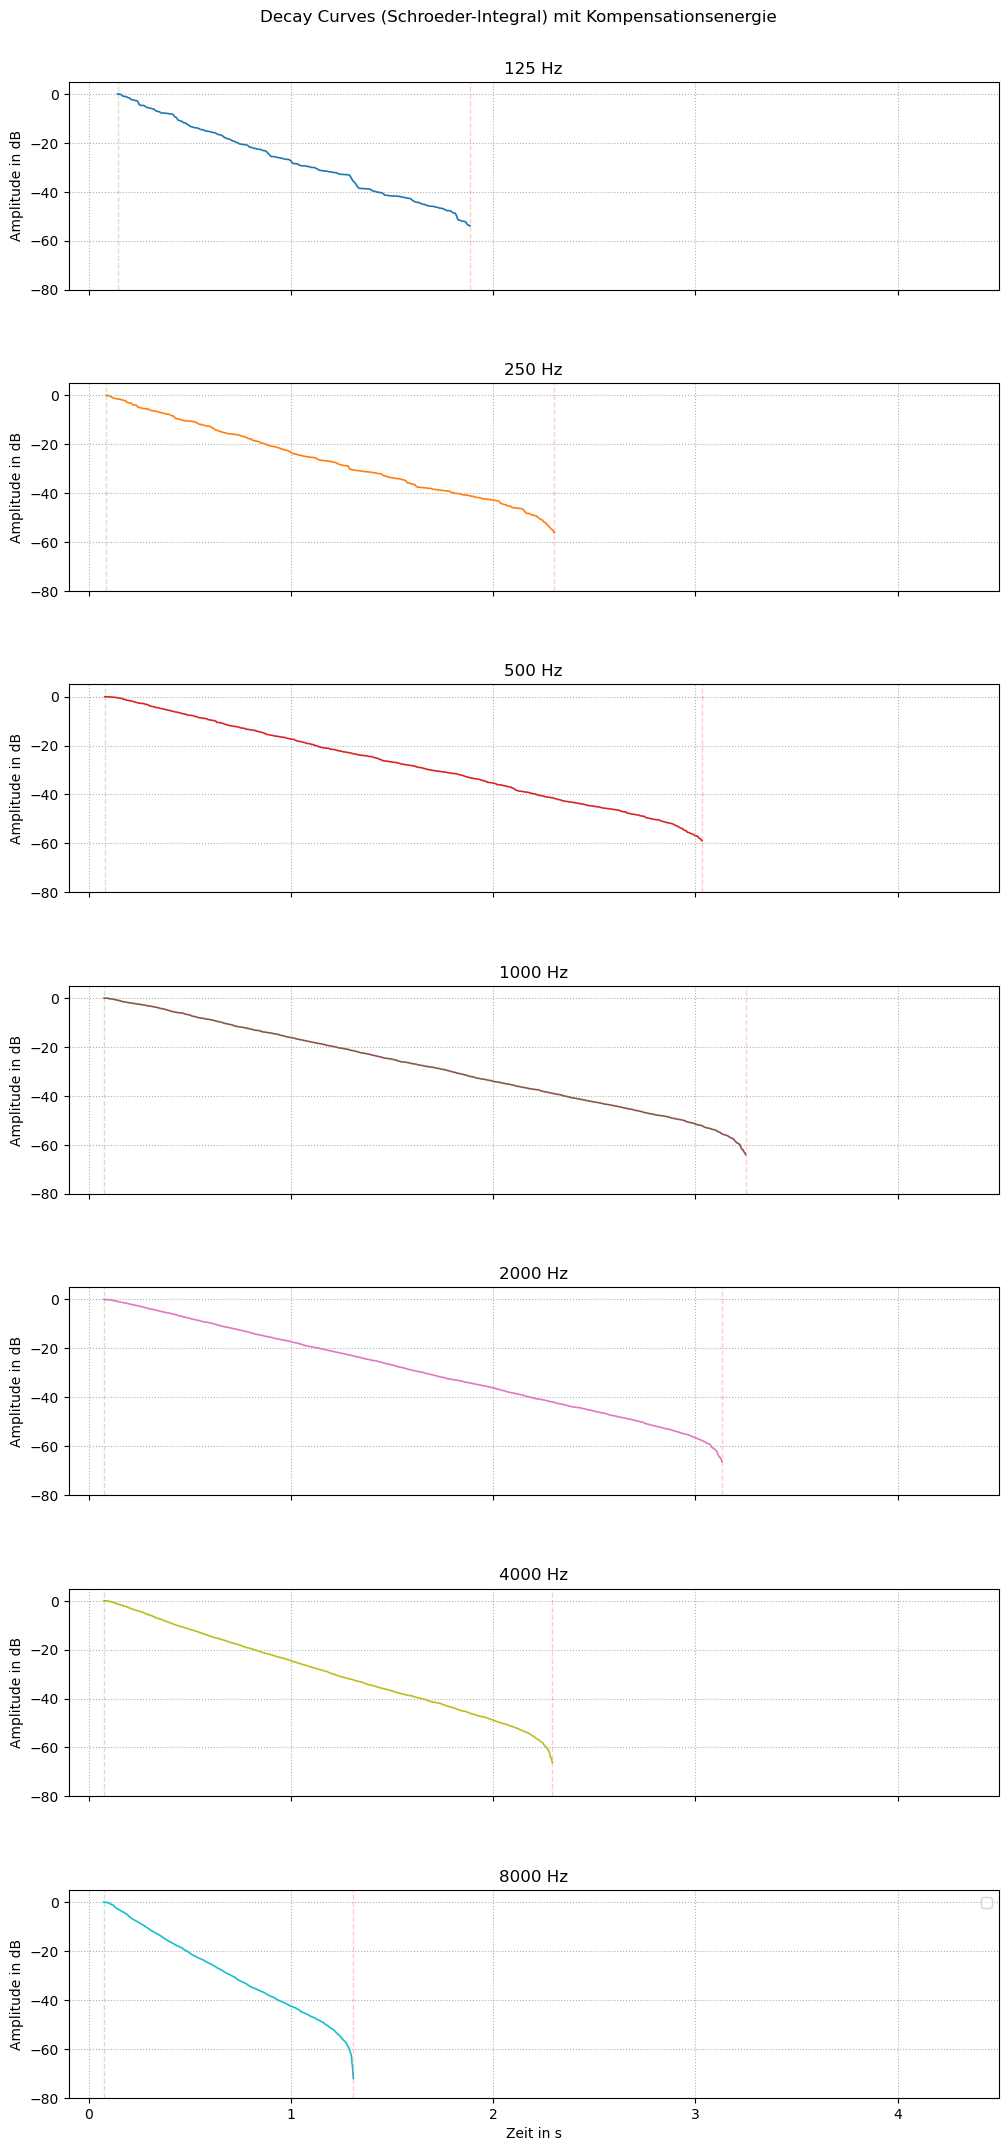

In [ ]:
# Loesung Aufgabe 2e

#Plot vorbereiten
fig, axes = plt.subplots(7, 1, figsize=(12, 24), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, 7))

edc_db_list = []

for i, fm in enumerate(f_m):
    x = np.squeeze(rir_bands.time[i])
    x2 = x**2

    # Start- und Endindex aus Zeiten bestimmen
    idx_start = np.searchsorted(t, t_start_array[i], side="left")
    idx_end = np.searchsorted(t, t_end_array[i], side="right") - 1

    idx_start = max(0, min(idx_start, len(t) - 1))
    idx_end = max(idx_start, min(idx_end, len(t) - 1))

    # Teil der Impulsantwort zwischen Start- und Endpunkt
    x2_seg = x2[idx_start:idx_end + 1]
    t_seg = t[idx_start:idx_end + 1]

    # Rückwärtsintegration Schröder-Integral
    edc_lin = np.cumsum(x2_seg[::-1])[::-1]

    # Kompensationsenergie für verdeckten Tail hinzufügen
    edc_lin = edc_lin + Ecomp_array[i]

    #Normierung auf ´Anfang der Decay Curve
    edc_db = 10 * np.log10(np.maximum(edc_lin / edc_lin[0], 1e-12))

    edc_db_list.append(edc_db)

    #Plot
    axes[i].plot(t_seg, edc_db, color=colors[i], linewidth=1.2)
    axes[i].axvline(t_start_array[i], color="green", alpha = 0.2, linestyle="--", linewidth=1, label="Anfang" if i == 0 else None)
    axes[i].axvline(t_end_array[i], color="red", alpha = 0.2, linestyle="--", linewidth=1, label="Ende" if i == 0 else None)

    axes[i].set_title(f"{int(fm)} Hz")
    axes[i].set_ylabel("Amplitude in dB")
    axes[i].grid(True, which="both", linestyle=":")
    axes[i].set_ylim(-80, 5)
    axes[i].set_xlim(-0.1, 4.5)

axes[-1].set_xlabel("Zeit in s")
fig.suptitle("Decay Curves (Schroeder-Integral) mit Kompensationsenergie", y=0.98)
fig.subplots_adjust(top=0.95, hspace=0.45)
plt.legend(loc="upper right")
plt.show()

f. Bestimmen Sie in Oktavbändern die Nachhallzeiten T10, T20 und T30 aus den Decay Curves als Steigung einer linearen Regressionsgeraden zwischen den in ISO 3382:2008 definierten Anfangs- und Endpunkten. 

Prüfen Sie jeweils, ob die für die Bestimmung von T10, T20 und T30 erforderlichen Signal-Rauschabstände nach ISO 3382:2008  gegeben sind und geben nur die Werte aus, bei denen dies der Fall ist. 

(3 Punkte)

In [9]:
# Loesung Aufgabe 2f

#Nachhallzeit aus Decay-Kurve bestimmen
def fit_rt_from_decay(t_seg, edc_db, db_hi, db_lo):
    # Relevanten Bereich der Kurve
    mask = (edc_db <= db_hi) & (edc_db >= db_lo)


    m, b = np.polyfit(t_seg[mask], edc_db[mask], 1)
    T = -60.0 / m
    return T, m

# Listen für Nachhallzeit-Werte
T10_list = []
T20_list = []
T30_list = []

# Berechnung für jedes Oktavband
for i, fm in enumerate(f_m):
    idx_start = np.searchsorted(t, t_start_array[i], side="left")
    idx_end = np.searchsorted(t, t_end_array[i], side="right") - 1

    idx_start = max(0, min(idx_start, len(t) - 1))
    idx_end = max(idx_start, min(idx_end, len(t) - 1))

    t_seg = t[idx_start:idx_end + 1]
    edc_db = np.asarray(edc_db_list[i])

    noise_floor_db = noise_floor_db_array[i]
    snr_db = -noise_floor_db

    T10, m10 = fit_rt_from_decay(t_seg, edc_db, -5, -15)
    T20, m20 = fit_rt_from_decay(t_seg, edc_db, -5, -25)
    T30, m30 = fit_rt_from_decay(t_seg, edc_db, -5, -35)

    T10_valid = snr_db >= 25
    T20_valid = snr_db >= 35
    T30_valid = snr_db >= 45

    T10_list.append(T10 if T10_valid else np.nan)
    T20_list.append(T20 if T20_valid else np.nan)
    T30_list.append(T30 if T30_valid else np.nan)

    print(f"Oktavband {int(fm)} Hz:")

    # Prints, wenn Bedingungen erfüllt
    if T10_valid and np.isfinite(T10):
        print(f"  T10: {T10:.3f} s   | SNR: {snr_db:.1f} dB")
    else:
        print(f"  T10: nicht verwendbar   | SNR: {snr_db:.1f} dB")

    if T20_valid and np.isfinite(T20):
        print(f"  T20: {T20:.3f} s   | SNR: {snr_db:.1f} dB")
    else:
        print(f"  T20: nicht verwendbar   | SNR: {snr_db:.1f} dB")

    if T30_valid and np.isfinite(T30):
        print(f"  T30: {T30:.3f} s   | SNR: {snr_db:.1f} dB")
    else:
        print(f"  T30: nicht verwendbar   | SNR: {snr_db:.1f} dB")

    print()

Oktavband 125 Hz:
  T10: 1.681 s   | SNR: 56.6 dB
  T20: 1.896 s   | SNR: 56.6 dB
  T30: 2.066 s   | SNR: 56.6 dB

Oktavband 250 Hz:
  T10: 2.492 s   | SNR: 57.0 dB
  T20: 2.425 s   | SNR: 57.0 dB
  T30: 2.564 s   | SNR: 57.0 dB

Oktavband 500 Hz:
  T10: 3.018 s   | SNR: 56.2 dB
  T20: 3.094 s   | SNR: 56.2 dB
  T30: 3.255 s   | SNR: 56.2 dB

Oktavband 1000 Hz:
  T10: 3.253 s   | SNR: 57.7 dB
  T20: 3.342 s   | SNR: 57.7 dB
  T30: 3.364 s   | SNR: 57.7 dB

Oktavband 2000 Hz:
  T10: 3.042 s   | SNR: 58.7 dB
  T20: 3.141 s   | SNR: 58.7 dB
  T30: 3.134 s   | SNR: 58.7 dB

Oktavband 4000 Hz:
  T10: 2.111 s   | SNR: 58.2 dB
  T20: 2.268 s   | SNR: 58.2 dB
  T30: 2.321 s   | SNR: 58.2 dB

Oktavband 8000 Hz:
  T10: 1.171 s   | SNR: 61.4 dB
  T20: 1.234 s   | SNR: 61.4 dB
  T30: 1.273 s   | SNR: 61.4 dB



Bei allen Werten werden die Grenzwerte eingehalten, dass der SNR bei T10 mind 25 dB, bei T20 mind 35dB und bei T30 mind 45dB ist.

g. Bestimmen Sie, unter Berücksichtigung der in c. bestimmten Anfangs- und Endpunkte sowie der in d. bestimmten Kompensationsenergie, die Werte für das Klarheitsmaß $C_{80}$ in Oktavbändern, sowie als Einzahlwert für die in DIN EN 3382-1:2008 vorgesehenen Oktavbänder. 

(2 Punkte)

In [10]:
# Loesung Aufgabe 2f

c80_list = []

dt = 1.0 / rir_bands.sampling_rate

for i, fm in enumerate(f_m):
    # bandgefilterte Impulsantwort
    x = np.squeeze(rir_bands.time[i])
    x2 = x**2

    # auf Max normieren, damit die Skalierung zur Ecomp aus 2d) passt
    x2_norm = x2 / np.max(x2)

    # Index für Start, 80ms, Ende
    idx_start = np.searchsorted(t, t_start_array[i], side="left")
    idx_80 = np.searchsorted(t, t_start_array[i] + 0.080, side="left")
    idx_end = np.searchsorted(t, t_end_array[i], side="right") - 1

    idx_start = max(0, min(idx_start, len(t) - 1))
    idx_80 = max(idx_start, min(idx_80, len(t) - 1))
    idx_end = max(idx_80, min(idx_end, len(t) - 1))

    # Früher Anteil bis 80 ms
    E_early = np.sum(x2_norm[idx_start:idx_80]) * dt

    # Später Anteil + Kompensationsenegie
    E_late_meas = np.sum(x2_norm[idx_80:idx_end + 1]) * dt
    E_late = E_late_meas + Ecomp_array[i]

    # C80 berechnen
    if E_early > 0 and E_late > 0:
        c80 = 10 * np.log10(E_early / E_late)
    else:
        c80 = np.nan

    c80_list.append(c80)

    print(f"Oktavband {int(fm)} Hz: C80 = {c80:.2f} dB")

# Array speichern
c80_array = np.array(c80_list)

# Einzahlwert: Mittelwert aus 500 Hz und 1000 Hz
idx_500 = np.where(np.isclose(f_m, 500))[0][0]
idx_1000 = np.where(np.isclose(f_m, 1000))[0][0]

c80_single = np.mean([c80_array[idx_500], c80_array[idx_1000]])
print(f"\nEinzahlwert C80 = {c80_single:.2f} dB")

Oktavband 125 Hz: C80 = -1.27 dB
Oktavband 250 Hz: C80 = -2.68 dB
Oktavband 500 Hz: C80 = -7.64 dB
Oktavband 1000 Hz: C80 = -5.13 dB
Oktavband 2000 Hz: C80 = -5.59 dB
Oktavband 4000 Hz: C80 = -3.40 dB
Oktavband 8000 Hz: C80 = 0.71 dB

Einzahlwert C80 = -6.39 dB


h. Vergleichen Sie Ihre Berechnungen mit den in 

Weinzierl, S., Sanvito, P., Schultz, F., & Büttner, C. (2015). The acoustics of renaissance theatres in Italy. Acta Acustica United with Acustica, 101(3), 632-641.

veröffentlichten Werten (Nachhallzeit und Klarheitsmaß) und nennen/diskutieren Sie drei Gründe für eine nicht perfekte Übereinstimmung. 

(2 Punkte)

*Lösung Aufgabe 2h hier*

Unser ermittelte Einzahlwert für $C_{80}$ liegt mit $-6.38\mathrm{dB}$ nicht weit entfernt vom Wert $-6.2\mathrm{dB}$ aus dem Paper an Position R2. 
Unsere ermittelte Nachhallzeit für $T_{20}$ bei  $1000\mathrm{Hz}$ von $3,342\mathrm{s}$ liegt ebenfalls nicht weit entfernt vom Wert $3,3\mathrm{s}$ aus dem Paper für einen Raum ohne Publikum.

Die Wahl der Messposition hat einen maßgeblichen Einfluss vor allem auf den Wert von $C_{80}$, wie die stark abweichenden Werte an den verschiedenen Positionen R1 - R9 zeigen. Verschiedene Reflexionen an verschiedenen Orten können auch zu Variationen in der gemessenen Nachhallzeit führen. Das lässt sich durch die Mittelung über verschiedene Messpunkte ausgleichen, was im Paper geschehen ist. Unsere Berechnungen hatten aber nur eine Impulsantwort als Grundlage.

Der Prozess der Aufbereitung von Anfangspunktbestimmung über Fensterung, Bandpassfilterung, Glättung, Noise-Floor-Schätzung, Lundeby-Kompensation und Schroeder-Integral kann mit verschiedenen Annahmen die Ergebnisse beeinflussen. Das Paper erwähnt zwar wie in unserem Fall die DIN 3382 als Grundlage, die genauen Schritte sind aber nicht im Detail dokumentiert, weshalb hier Abweichungen auftreten können.

Ein weiterer möglicher Grund für Abweichungen ist die jahreszeitlich unterschiedliche Temperatur bzw. der Betriebszustand des Raums. Das Paper nennt hierzu keine Temperatur- oder Luftfeuchtigkeitsbedingungen, die Einfluss auf die Raumakustik haben können. Unterschiedliche Messbedingungen im Sommer und Winter können daher die akustischen Kennwerte zusätzlich beeinflussen, falls die uns vorliegende und die Impulsantwort aus dem Paper unter verschiedenen Bedingungen aufgenommen wurde.


i. Verwenden Sie die im Oktavband mit der Mittenfrequenz **1000 Hz** in Aufgabe f. bestimmte Nachhallzeit **T20** und berechnen daraus den Wert für $C_{80}$, der sich unter der Annahme eines **perfekt exponentiellen Abfalls** ergäbe (statistische Raumakustik). 

Vergleichen Sie diesen Wert mit dem empirisch bestimmten Wert in Aufgabe g. 

(2 Punkte) 

In [11]:
# Lösung Aufgabe 2i

# Gegeben
T20_1000 = 3.342 # in Sekunden
C80_emp = -5.13

# Abklingkonstante aus T20 berechnen
gamma = np.log(100) / T20_1000

# C80 für exp Abfall
C80_stat = 10 * np.log10((1-np.exp(-gamma * 0.08))/ (np.exp(-gamma * 0.08)))

# Vergleich
diff = C80_emp - C80_stat

print(f"T20 (1000 Hz):      {T20_1000:.3f} s")
print(f"C80 statistisch:    {C80_stat:.2f} dB")
print(f"C80 empirisch:      {C80_emp:.2f} dB")
print(f"Differenz:          {diff:.2f} dB")

T20 (1000 Hz):      3.342 s
C80 statistisch:    -9.34 dB
C80 empirisch:      -5.13 dB
Differenz:          4.21 dB


Der empirisch gemessene Wert liefert ein um $4.21\mathrm{dB}$ besseres Klarheitsmaß. Eine Berechnung des Klarheitsmaßes über die Nachhallzeit $T_20$ alleine ist deutlich ungenauer, da die tatsächlichen frühen Reflexionen nicht berücksichtigt werden und in der Realität anders als im statistischen Modell sind. In diesem Fall sind sie deutlich stärker und da sie maßgeblich für das Klarheitsmaß sind, fällt das empirisch ermittelte Klarheitsmaß besser aus.